# 02 — Customer Segmentation

K-Means segmentation of the 996 credit-card customers. Feeds **report §4 (Customer Segmentation)**.

The clustering itself is produced by the DVC pipeline
(`src/models/train_segmentation.py` → `dvc repro train_segmentation`); this
notebook **selects, validates, profiles, names and interprets** the result.
Preprocessing inside the fitted pipeline is
`Winsorize[1%,99%] → median-impute → Yeo-Johnson → PCA(2)`, which de-skews the
whale-dominated monetary features that otherwise collapse K-Means to k=2.

In [1]:
import sys
from pathlib import Path
import json

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Resolve repo root whether the notebook runs from notebooks/ or the root.
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.models.train_segmentation import _preprocess  # same recipe as the pipeline

# Canonical pipeline outputs: segment labels are the model's assignments.
seg = pd.read_parquet(ROOT / "data" / "processed" / "customer_segments.parquet")
metrics = json.load(open(ROOT / "metrics" / "segmentation.json"))
seg_params = yaml.safe_load(open(ROOT / "params.yaml"))["segmentation"]
FEATURES = seg_params["features"]
labels = seg["segment"].to_numpy()

# Rebuild the 2-D PCA embedding deterministically (Winsorize -> impute ->
# Yeo-Johnson -> PCA) to reproduce the model's geometry for plots and the
# algorithm comparison, without unpickling the custom-class model.
Xp = _preprocess(seg_params).fit_transform(seg[FEATURES])
print(f"{len(seg):,} customers | k={metrics['best_k']} | "
      f"silhouette={metrics['best_silhouette']:.3f}")

996 customers | k=6 | silhouette=0.408


## 1. Choosing k and the algorithm

We searched K-Means over k ∈ [2, 8] and picked the silhouette peak. We then
cross-check the winning solution against two other algorithms — the segments
should be a property of the *data*, not of one method.

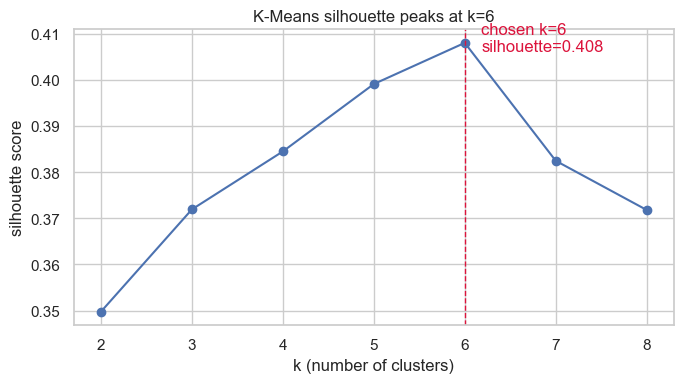

In [2]:
sk = {int(k): v for k, v in metrics["silhouette_by_k"].items()}
best = metrics["best_k"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(sk), list(sk.values()), marker="o")
ax.axvline(best, color="crimson", ls="--", lw=1)
ax.annotate(f"chosen k={best}\nsilhouette={sk[best]:.3f}", (best, sk[best]),
            textcoords="offset points", xytext=(12, -6), color="crimson")
ax.set(xlabel="k (number of clusters)", ylabel="silhouette score",
       title="K-Means silhouette peaks at k=6")
plt.tight_layout(); plt.show()

In [3]:
# Robustness: same k, three algorithms, on the identical PCA space.
ag = AgglomerativeClustering(n_clusters=best).fit_predict(Xp)
gm = GaussianMixture(n_components=best, random_state=42, n_init=5).fit_predict(Xp)

comp = pd.DataFrame({
    "silhouette": [silhouette_score(Xp, m) for m in (labels, ag, gm)],
    "ARI vs K-Means": [1.0, adjusted_rand_score(labels, ag),
                       adjusted_rand_score(labels, gm)],
}, index=["K-Means (chosen)", "Agglomerative (Ward)", "Gaussian Mixture"])
comp.round(3)

,silhouette,ARI vs K-Means
K-Means (chosen),0.41,1.00
Agglomerative (Ward),0.32,0.47
Gaussian Mixture,0.30,0.58


**Why k=6 + K-Means.** Silhouette rises monotonically from k=2 (0.35) to a
clear interior peak at **k=6 (0.41)** and falls thereafter — a genuine elbow,
not the degenerate "whales vs. everyone" k=2 we saw before de-skewing.
K-Means gives the cleanest separation (silhouette 0.41 vs. 0.32 Ward, 0.31
GMM), and its partition agrees substantially with the probabilistic GMM
(ARI ≈ 0.58) and moderately with Ward (ARI ≈ 0.47). The six groups are
therefore a stable feature of the data, and we keep the simplest, most
interpretable model.

## 2. Profiling and naming the segments

Profiles are computed on the **original, untransformed** variables (the
Yeo-Johnson space is for distance only — it is not interpretable in business
terms). Each segment is named from its distinguishing behaviour.

In [4]:
# Names are tied to cluster *behaviour*. The asserts fail loudly if a re-run
# ever renumbers clusters, so the labels can never silently drift.
NAMES = {
    4: "High-Value Whales",
    5: "Affluent Transactors",
    3: "Engaged Revolvers",
    0: "Core Transactors",
    1: "Credit-Constrained Revolvers",
    2: "Dormant / At-Risk",
}
assert seg.groupby("segment")["total_spend"].median().idxmax() == 4, "renumbered: revisit NAMES"
assert seg.groupby("segment")["credit_utilisation"].median().idxmax() == 1, "renumbered: revisit NAMES"
assert seg.groupby("segment")["churn_risk"].mean().idxmax() == 2, "renumbered: revisit NAMES"
seg["segment_name"] = seg["segment"].map(NAMES)

In [5]:
PROFILE = ["total_spend", "txn_count", "avg_txn_amount", "credit_limit",
           "credit_utilisation", "payment_ratio", "n_merchant_groups",
           "recency_days", "churn_risk"]

prof = seg.groupby(["segment", "segment_name"]).agg(
    customers=("segment", "size"),
    **{c: (c, "median") for c in PROFILE},
)
prof["pct_customers"] = prof["customers"] / len(seg) * 100
prof["pct_of_spend"] = (seg.groupby(["segment", "segment_name"])["total_spend"].sum()
                        / seg["total_spend"].sum() * 100)
prof = prof.sort_values("pct_of_spend", ascending=False)
prof.round(2)

,,customers,total_spend,txn_count,avg_txn_amount,credit_limit,credit_utilisation,payment_ratio,n_merchant_groups,recency_days,churn_risk,pct_customers,pct_of_spend
segment,segment_name,,,,,,,,,,,,
5,Affluent Transactors,171,"148,744.72",250.00,635.84,"40,000.00",0.03,0.74,19.00,19.00,0.00,17.17,35.78
4,High-Value Whales,60,"355,191.76",378.50,922.46,"60,500.00",0.41,0.11,25.00,17.00,0.00,6.02,35.37
3,Engaged Revolvers,189,"59,673.48",145.00,403.19,"15,000.00",0.66,0.08,14.00,18.00,0.00,18.98,13.46
0,Core Transactors,279,"33,415.03",89.00,354.80,"16,000.00",0.03,0.44,10.00,19.00,0.00,28.01,11.30
1,Credit-Constrained Revolvers,204,"15,703.38",68.50,213.14,"6,000.00",0.72,0.07,7.00,20.00,0.00,20.48,3.55
2,Dormant / At-Risk,93,"4,354.35",24.00,141.48,"12,000.00",0.00,0.07,2.00,31.00,1.00,9.34,0.54


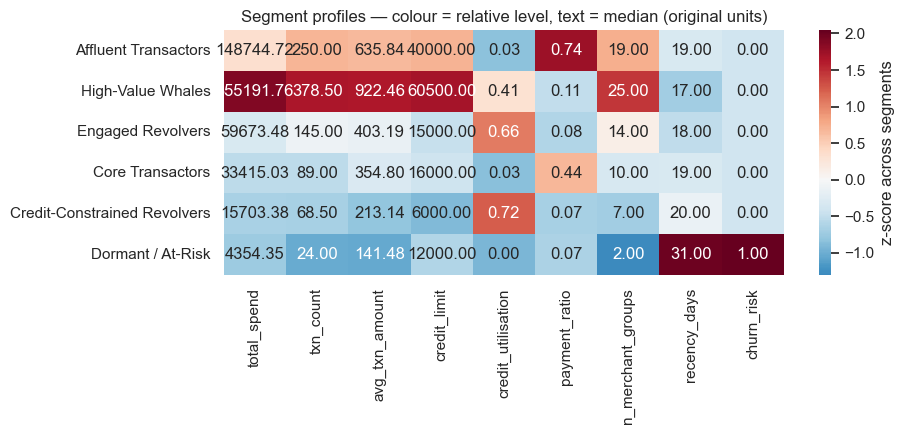

In [6]:
# Heatmap: colour = how each segment deviates from the average segment
# (z-score across the 6 medians); cell text = the median in original units.
order = prof.index.get_level_values("segment_name")
hm = seg.groupby("segment_name")[PROFILE].median().loc[order]
hmz = (hm - hm.mean()) / hm.std()

fig, ax = plt.subplots(figsize=(9.5, 4.5))
sns.heatmap(hmz, annot=hm.round(2), fmt=".2f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "z-score across segments"}, ax=ax)
ax.set(title="Segment profiles — colour = relative level, text = median (original units)",
       ylabel="")
plt.tight_layout(); plt.show()

## 3. Economic weight — where the money is

Customer counts alone are misleading: the segments differ in spend by two
orders of magnitude. The chart contrasts each segment's **share of customers**
with its **share of total spend**.

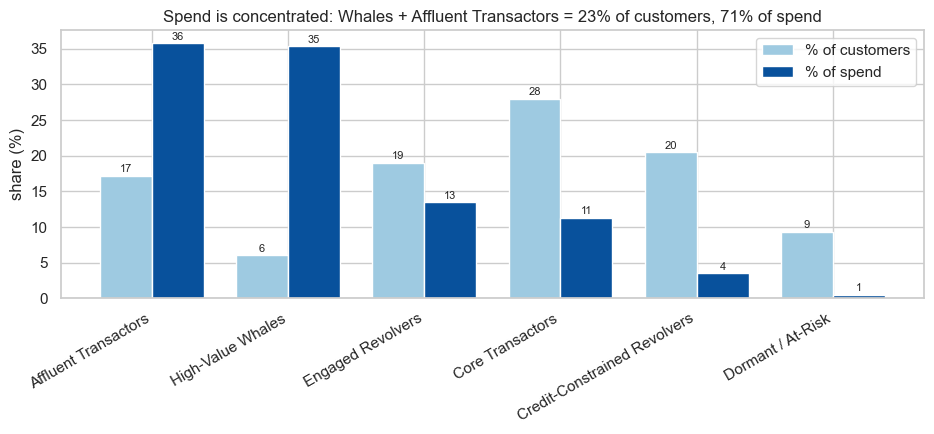

In [7]:
x = np.arange(len(order)); w = 0.38
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.bar(x - w/2, prof["pct_customers"], w, label="% of customers", color="#9ecae1")
ax.bar(x + w/2, prof["pct_of_spend"], w, label="% of spend", color="#08519c")
for i, (c, s) in enumerate(zip(prof["pct_customers"], prof["pct_of_spend"])):
    ax.text(i - w/2, c + 0.5, f"{c:.0f}", ha="center", fontsize=8)
    ax.text(i + w/2, s + 0.5, f"{s:.0f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=30, ha="right")
ax.set(ylabel="share (%)",
       title="Spend is concentrated: Whales + Affluent Transactors = 23% of customers, 71% of spend")
ax.legend(); plt.tight_layout(); plt.show()

## 4. Segment map (2-D PCA projection)

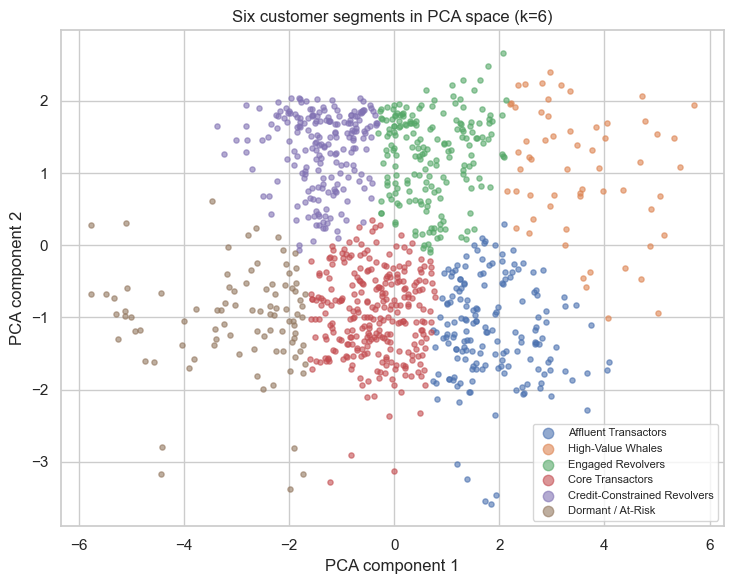

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 6))
for name in order:
    m = (seg["segment_name"] == name).to_numpy()
    ax.scatter(Xp[m, 0], Xp[m, 1], s=14, alpha=0.6, label=name)
ax.set(xlabel="PCA component 1", ylabel="PCA component 2",
       title="Six customer segments in PCA space (k=6)")
ax.legend(markerscale=2, fontsize=8, loc="best")
plt.tight_layout(); plt.show()

## 5. Business interpretation & recommendations → report §4 / §8

Segments ordered by economic weight. Every recommendation ties to a measurable
behaviour and a revenue or risk lever.

| Segment | Size | % spend | Defining behaviour | Recommended action |
|---|---|---|---|---|
| **High-Value Whales** | 60 (6%) | **35%** | Median spend ~355k across 25 merchant groups; 60.5k limit; lowest churn (7%) | **Protect at all costs.** Dedicated relationship management, premium rewards, proactive retention. A whale spends ~9× the median customer ($355k vs $39k) — this is concentration risk, not just opportunity. |
| **Affluent Transactors** | 171 (17%) | **36%** | High spend (~149k), pay-in-full (utilisation 3%, payment ratio 0.74) — interchange revenue, almost no interest | **Grow share-of-wallet.** Premium card upsell, travel/lifestyle rewards, cross-sell wealth/investment products. Little credit risk. |
| **Engaged Revolvers** | 189 (19%) | 14% | Active & broad (145 txns, 14 groups) but carry balances (utilisation 66%, payment ratio 0.08) | **The interest-income engine.** Responsible credit-line increases for good payers, balance-transfer offers; monitor for rising delinquency. |
| **Core Transactors** | 279 (28%) | 11% | Mainstream mid-spend (~33k), low utilisation (3%), 10 merchant groups | **Largest base — nudge upward.** Category-targeted rewards and spend-stimulus offers to migrate the best toward Affluent Transactor behaviour. |
| **Credit-Constrained Revolvers** | 204 (20%) | 4% | Low limit (6k), maxed out (utilisation 72%), carry balances, elevated churn (24%) | **Risk-managed growth.** Selective limit reviews for creditworthy customers; tighten monitoring on the rest. Small wallet — keep acquisition/servicing cost low. |
| **Dormant / At-Risk** | 93 (9%) | 0.5% | Barely active (24 txns, 2 groups), **53% churn-flagged** | **Reactivate cheaply or let lapse.** One low-cost win-back campaign; do not over-invest — this segment is 0.5% of spend. |

**Call to action.** Retention and relationship investment should be ranked by
**spend at risk, not headcount**: the 231 customers in *Whales* + *Affluent
Transactors* (23% of the base) generate **71% of spend** and must be the
priority for retention and premium service, while the 297 customers in
*Credit-Constrained Revolvers* + *Dormant* (30% of the base, <5% of spend) are
managed for **cost and risk**, not growth. The *Engaged Revolvers* are the bank's
main interest-income source and warrant a dedicated credit-line / risk strategy.